# 1.1 Radial velocity analysis of WASP-12b 

### Universidad de La Laguna Exo & Exo 2024-2025 exercise 1

Author: [Hannu Parviainen](mailto:hannu@iac.es)<br>
Last updated: 21.4.2025

This first exercise teaches you how to estimate the minimum planetary mass from radial velocity measurements using [Bayesian inference](https://en.wikipedia.org/wiki/Bayesian_inference).


## (The absolute basics of) radial velocities

A planet orbiting a star causes the star to [move around the star-planet barycentre](https://exoplanets.nasa.gov/alien-worlds/ways-to-find-a-planet/#/1). This leads to a periodic change in the star's position and velocity,
and the radial component of the star's velocity can be measured using [doppler spectroscopy](https://en.wikipedia.org/wiki/Doppler_spectroscopy). Radial velocity (RV) measurements are used to search for unknown planets and to estimate the minimum masses and orbital periods of known planets.

![Doppler shift vs time](Doppler_Shift_vs_Time.svg "Doppler shift vs time")


A planet with a mass $M_\mathrm{p}$ orbiting a star with a mass $M_\star$ with an orbital period $P$ leads to a periodic signal with a semi-amplitude of

$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

where $G$ is the [gravitational constant](https://en.wikipedia.org/wiki/Gravitational_constant), $e$ is the [orbital eccentricity](https://en.wikipedia.org/wiki/Orbital_eccentricity), and $i$ is the [orbital inclination](https://en.wikipedia.org/wiki/Orbital_inclination). After we estimate $P$, $K$, and $M_\star$ we can solve for the minimum planetary mass $M_\mathrm{p} \sin i$. The orbital period and RV semi-amplitude can be estimated directly from the RV signal, but the stellar mass needs to be estimated using other means.


## (The absolute basics of) Bayesian parameter estimation

Measuring the RV semi-amplitude and the orbital period from RV measurements is a *parameter estimation* problem: we assume we have an adequate model to describe the observations, and we want to infer the model parameters with their uncertainties.

We take a [*Bayesian*](http://en.wikipedia.org/wiki/Bayesian_probability) approach to the parameter estimation, where we want to estimate the [*posterior probability*](http://en.wikipedia.org/wiki/Posterior_probability) for the model parameters given their [*prior probabilities*](http://en.wikipedia.org/wiki/Prior_probability) and a set of observations. The posterior probability density given a parameter vector $\theta$ and observational data $D$ is described by the [*Bayes' theorem*](http://en.wikipedia.org/wiki/Bayes%27_theorem) as

$$
P(\theta|D) = \frac{P(\theta) P(D|\theta)}{P(D)}, \qquad P(D|\theta) = \prod P(D_i|\theta),
$$

where $P(\theta)$ is the prior, $P(D|\theta)$ is the [*likelihood*](http://en.wikipedia.org/wiki/Likelihood_function) for the data, and $P(D)$ is a [*normalising factor*](http://en.wikipedia.org/wiki/Marginal_likelihood) we don't need to bother with during MCMC-based parameter estimation. 

The likelihood is a product of individual observation probabilities, and has the unfortunate tendency to end up being either very small or very big. This causes computational headaches, and it is better to work with log probabilities instead, so that

$$
\log P(\theta|D) = \log P(\theta) + \log P(D|\theta),  \qquad \log P(D|\theta) = \sum \log P(D_i|\theta)
$$

where we have omitted the $P(D)$ term from the posterior density.

Now we still need to decide our likelihood density. If we can assume normally distributed white noise--that is, the errors in the observations are independent and identically distributed--we end up with a log likelihood function

$$
 \log P(D|\theta) = -N\log(\sigma) -\frac{N\log 2\pi}{2} - \sum_{i=0}^N \frac{(o_i-m_i)^2}{2\sigma^2},
$$

where $N$ is the number of datapoints, $\sigma$ is the white noise standard deviation, $o$ is the observed data, and $m$ is the model. 

This should be enough for these exercies, but you can find more information from [A primer about Bayesian statistics](https://ui.adsabs.harvard.edu/link_gateway/2018haex.bookE.149P/EPRINT_PDF) and the references therein.

## Initialisation

In [44]:
%matplotlib inline

In [45]:
import pandas as pd
import astropy.units as u

from matplotlib.pyplot import subplots, setp, rc, Rectangle
from numpy import argmax, median
from astropy.table import Table
from astropy.timeseries import LombScargle
from corner import corner

from pytransit.lpf.rvlpf import RVLPF

rc('figure', figsize=(13,4))

## 1.1 Read in the RV data 

The radial velocity measurements consist of mid-observation times, radial velocity values, and radial velocity measurement uncertainties (also called as 'errors'). We use the data from [Yee et al. (2019)](https://iopscience.iop.org/article/10.3847/2041-8213/ab5c16). The data is stored as a CDS table that can be read directly using `astropy.table.Table`.

In [46]:
rv_data = Table.read('data/wasp_12b_yee_2019.dat', format='ascii.cds')

It's important to understand what sort of data we're dealing with, so we begin by displaying the table header and the five first rows.

In [47]:
rv_data[:5]  

BJD,RVel,e_RVel
d,m / s,m / s
float64,float64,float64
2455521.959432,-136.635,2.534
2455543.089922,5.728,2.919
2455545.983884,-162.39,2.822
2455559.906718,141.616,2.345
2455559.917563,115.818,2.727


It's also useful to visualise directly what we're working with, so we next plot the radial velocity data and its uncertainties as a function of time.

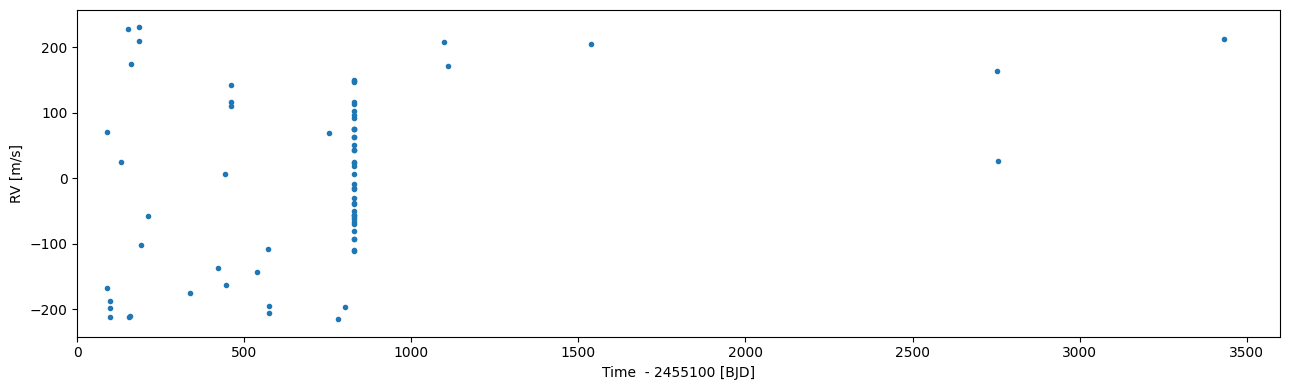

In [48]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time  - 2455100 [BJD]', ylabel='RV [m/s]', xlim=(0, 3600))
fig.tight_layout()

### <span style="color:darkblue">Questions and exercises:</span>

1. Try to describe the logic behind the time sampling of the RV observations.

The radial velocity observations are grouped into short time intervals, indicating intensive observation campaigns when the star was visible or observational conditions allowed. Between these intervals, there are large gaps, likely caused by the star being unobservable due to its position in the sky or telescope scheduling constraints.

2. Plot below the RV observations as a function of time focusing on the densely-sampled time-span.

The plot shows the radial velocity measurements of WASP-12b focused on the densest time span of observations. A tight cluster of data points is evident around 825 days (relative to BJD - 2455100), allowing for a detailed view of the planet’s orbital motion during this phase. The dense sampling improves the precision in determining the orbital parameters and the radial velocity curve shape. 

Below is the Python code used to generate this plot:

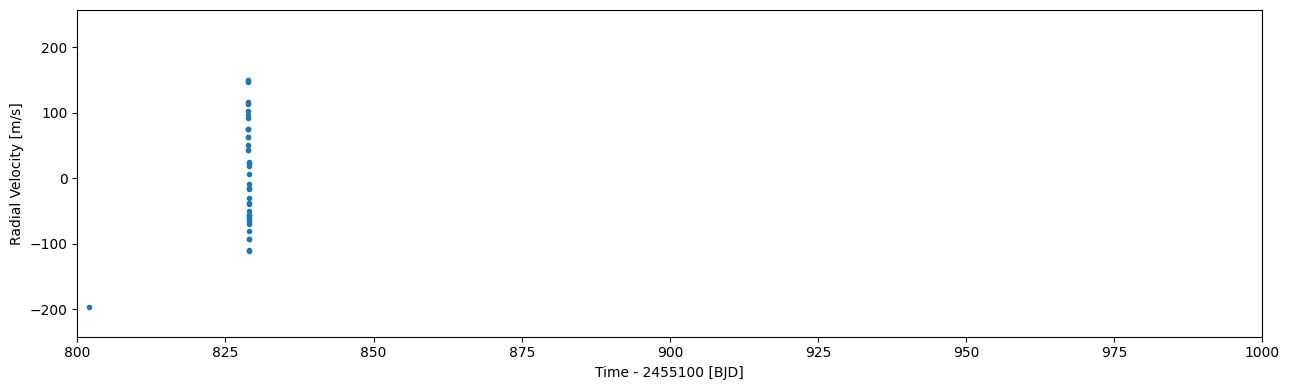

In [49]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] - 2455100, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Time - 2455100 [BJD]', ylabel='Radial Velocity [m/s]', xlim=(800, 1000))
fig.tight_layout()

## 1.2 Search for a radial velocity signal

First, we use a Lomb-Scargle periodigram to search for a sinusoidial radial velocity signal from the RV measurements. This is simple to do with `astropy.timeseries.LombScargle` class that is initialised with the mid-measurement times and the RV observations.

In [50]:
ls = LombScargle(rv_data['BJD'], rv_data['RVel'])

Next, we use the `LombScargle.autopower` to calculate the periodogram. We restrict the search to $0.5 < P < 5$ days.

In [51]:
frequency, power = ls.autopower(minimum_frequency=1/(5*u.d), maximum_frequency=2/u.d)
period = 1/frequency

In [52]:
best_period = period[argmax(power)]
best_period

<Quantity 1.09144998 d>

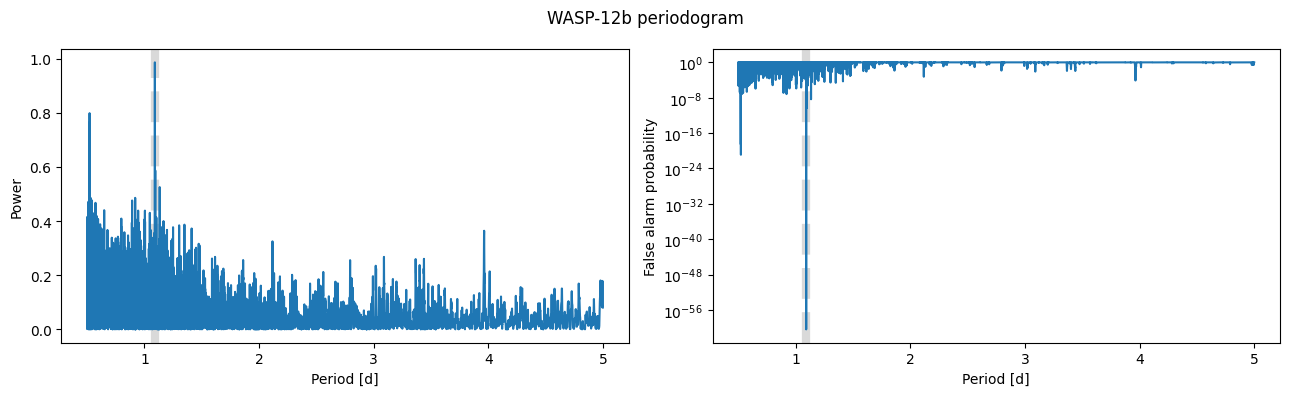

In [53]:
fig, axs = subplots(1, 2, figsize=(13,4))
axs[0].plot(period, power)
axs[1].semilogy(period, ls.false_alarm_probability(power))
[ax.axvline(best_period.value, c='k', ls='--', zorder=-1, lw=6, alpha=0.15) for ax in axs]
setp(axs, xlabel='Period [d]')
setp(axs[0], ylabel='Power')
setp(axs[1], ylabel='False alarm probability')
fig.suptitle('WASP-12b periodogram')
fig.tight_layout()

Let's see what happens when we plot the RV values folded over the best period.

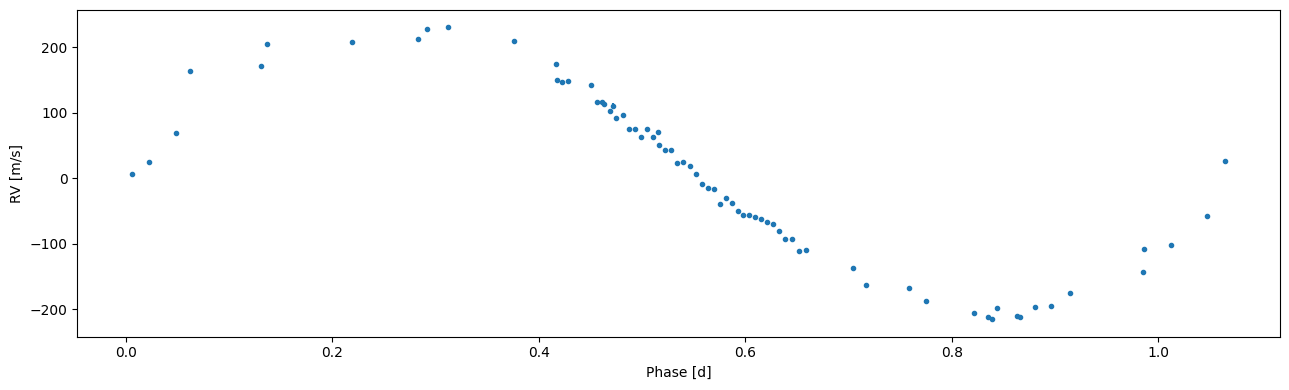

In [54]:
fig, ax = subplots()
ax.errorbar(rv_data['BJD'] % best_period.value, rv_data['RVel'], rv_data['e_RVel'], fmt='.')
setp(ax, xlabel='Phase [d]', ylabel='RV [m/s]')
fig.tight_layout()

## 1.3 Radial velocity modelling

Now when we know the RV data contains a suspicious signal, we can model it to study what sort of an object is causing it. The two most important parameters we're interested are the orbital period and radial velocity semiamplitude (K). The RV semiamplitude will give us the lower limit of the object's mass ($m\sin i$) which will then tell us whether we're dealing with a planet or something else.

### Initialise the model

In [55]:
lpf = RVLPF('WASP-12b', 1, rv_data['BJD'], rv_data['RVel'], rv_data['e_RVel'])

In [56]:
lpf.ps

[  0 |G| tc_1           N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.0, σ = 1e-05)                    [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 0.1)                      [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 1.0)                      [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 1.0)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     N(μ = 0.0, σ = 1.0)                      [    -inf ..      inf]]

The parameters are

- `tc_1`: transit center [BJD]
- `p_1`: orbital period [d]
- `secw_1`: $\sqrt{e} \cos\omega$, where $e$ is the eccentricity and $\omega$ the argument of periastron
- `sesw_1`: $\sqrt{e} \sin\omega$
- `rv_shift_0`: systemic velocity [m/s]
- `rv_err_0`: additional white noise [m/s]
- `rv_k_1` RV semiamplitude [m/s]
- `rv_slope`: additional linear slope

### Set the parameter priors

Bayesian inference requires a prior probability distribution for each of our model parameters. These "priors" can be based on previous studies, theoretical expectations, or more generally in our beliefs on what values the parameters can take.

In this case we use two priors: a normal prior (NP) and a uniform prior (UP). The normal prior models our prior belief using a normal distribution with a known mean and standard deviation, while the uniform prior says that the paramer can take any value between a minimum and maximum boundary.

In [57]:
lpf.set_prior('tc_1', 'NP', 2458480.65, 0.02) # Normal prior (mean, sigma)
lpf.set_prior('p_1', 'NP', 1.09, 0.1)
lpf.set_prior('rv_shift_0', 'NP', 0.0, 10)
lpf.set_prior('rv_err_0', 'UP', 0.0, 30.0) # Uniform prior (min, max)
lpf.set_prior('rv_k_1', 'UP', 0.0, 300)
lpf.set_prior('rv_slope_1', 'UP', 0.0, 1e-5)

In [58]:
lpf.ps

[  0 |G| tc_1           N(μ = 2458480.65, σ = 0.02)              [    -inf ..      inf],
   1 |G| p_1            N(μ = 1.09, σ = 0.1)                     [    0.00 ..      inf],
   2 |G| secw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   3 |G| sesw_1         U(a = -1.0, b = 1.0)                     [   -1.00 ..     1.00],
   4 |G| rv_shift_0     N(μ = 0.0, σ = 10.0)                     [    -inf ..      inf],
   5 |G| rv_err_0       U(a = 0.0, b = 30.0)                     [    -inf ..      inf],
   6 |G| rv_k_1         U(a = 0.0, b = 300)                      [    0.00 ..      inf],
   7 |G| rv_slope_1     U(a = 0.0, b = 1e-05)                    [    -inf ..      inf]]

### Fit the model to the data

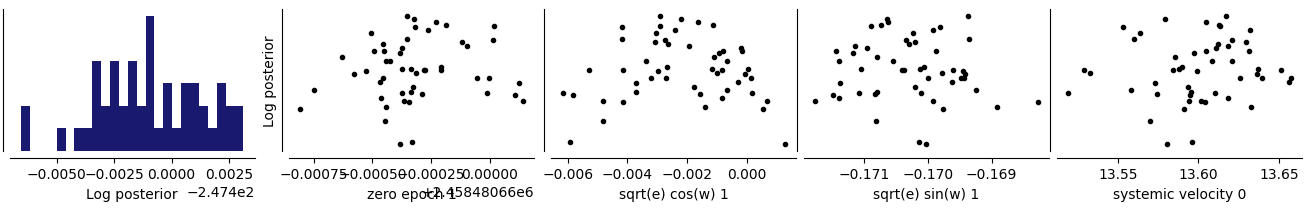

In [59]:
lpf.optimize_global(2000)

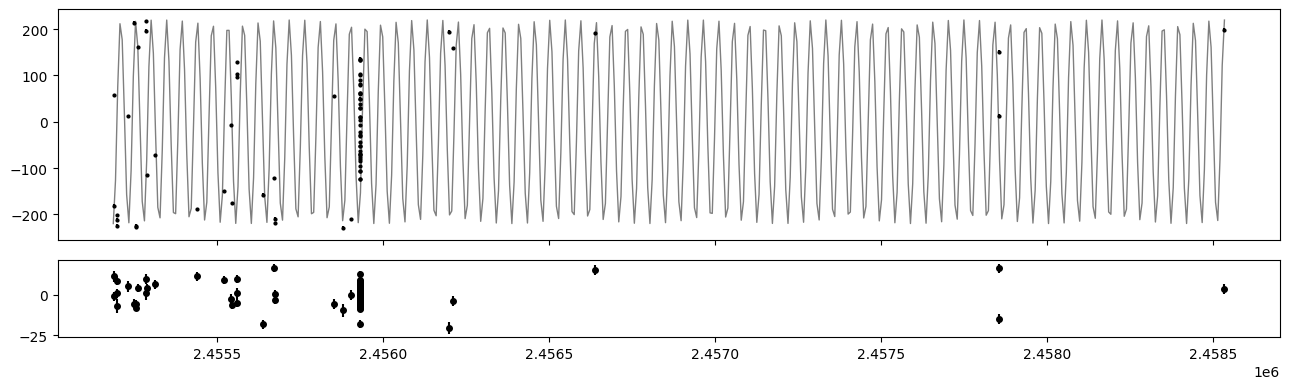

In [60]:
lpf.plot_rv_vs_time();

/Users/mariomanzano/spyder_env/lib/python3.13/site-packages/pytransit/lpf/rvlpf.py:370: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  axs[0].errorbar(phase[m], rvs[m], self._rvea[m], fmt='o', marker=markers[iid],


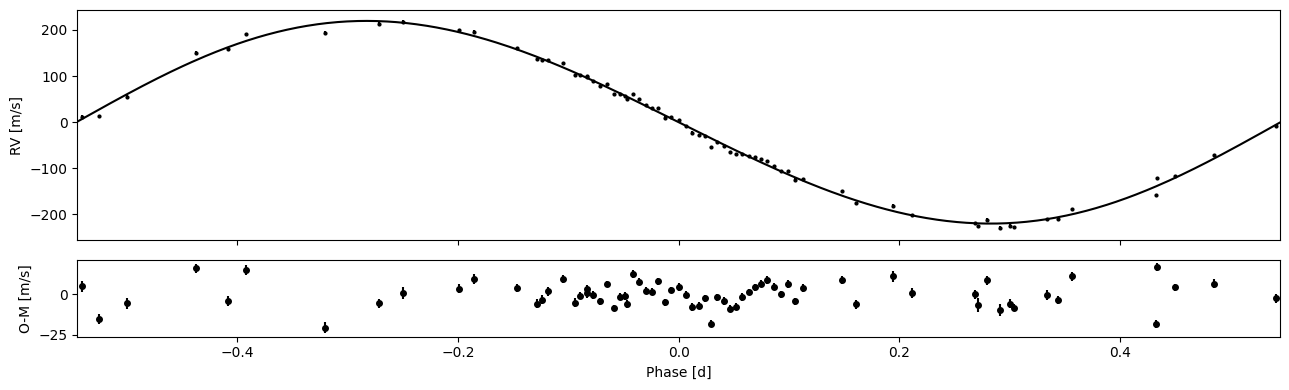

In [61]:
lpf.plot_rv_vs_phase(0);

### Estimate the parameter posterior distributions using MCMC

We estimate the [posterior probability distributions](https://en.wikipedia.org/wiki/Posterior_probability) of our model parameters using [Markov Chain Monte Carlo sampling](https://twiecki.io/blog/2015/11/10/mcmc-sampling). The sampling can be done using the `RVLPF.sample_mcmc` method after a global optimisation run has been finished. The `sample_mcmc` method uses the [*emcee*](https://emcee.readthedocs.io/en/stable) sampler under the hood.

We give `RVLPF.sample_mcmc` the number of MCMC steps to take (`niter`), a thinning factor (`thin`), and a number of repeats (`repeats`). This makes the sampler run first one round of `niter` steps, restarts the sampler from the last step of the previous run, and run again `niter` steps. This is the same as running the sampler for `2 x niter` and keeping only the second half of the steps. The first half is treated as a [warm-up period](https://stats.stackexchange.com/questions/88819/mcmc-methods-burning-samples) for the sampler and discarded. In general, the sampler is run `repeats x niter` steps in total, and only the last `niter` steps are retained.

The thinning factor tells the sampler to store only every $n$th step. In our case, we're storing only every 10th step. Thinning is a way to try to store only statistically independent samples, but is [not really necessary](https://besjournals.onlinelibrary.wiley.com/doi/pdf/10.1111/j.2041-210X.2011.00131.x). However, we'll do it to keep the number of samples low (there's no point in storing a large number of dependent samples either).

In [62]:
lpf.sample_mcmc(niter=2000, thin=10, repeats=2)

MCMC sampling: 100%|██████████| 2/2 [00:10<00:00,  5.01s/it] 


The *emcee* sampler uses an ensemble of MCMC chains to sample the posterior. This means that we have many chains running in parallel. We can plot the traces of each chain to see how the chain population behaves in time.

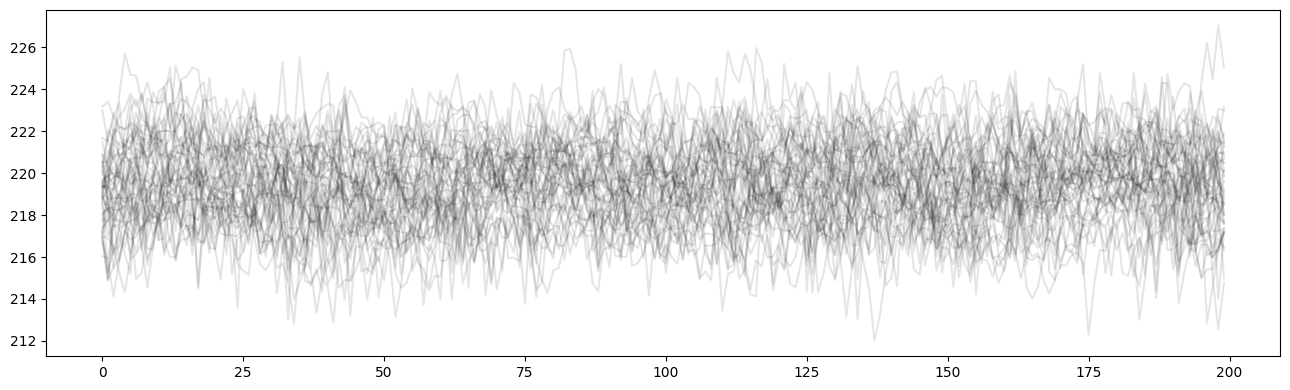

In [63]:
lpf.plot_mcmc_chains(6);

### Plot the model posterior

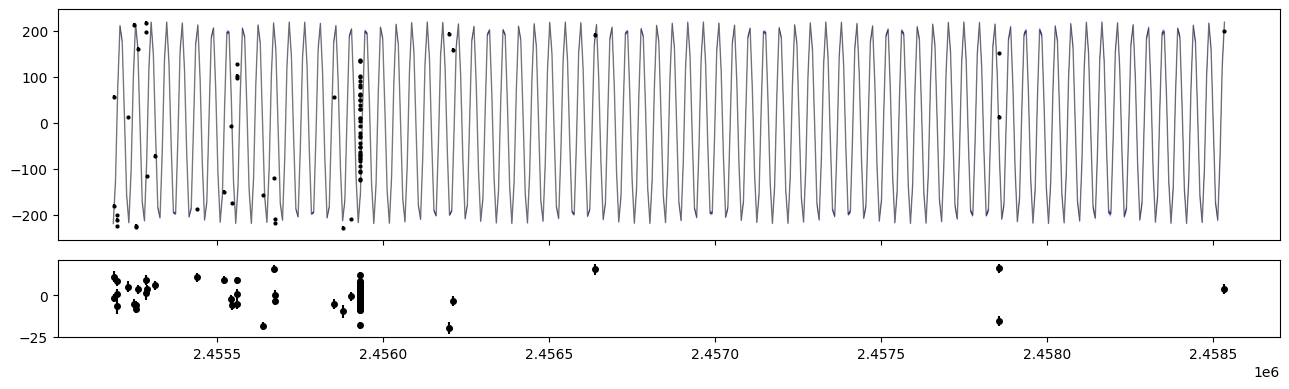

In [64]:
lpf.plot_rv_vs_time('mcmc');

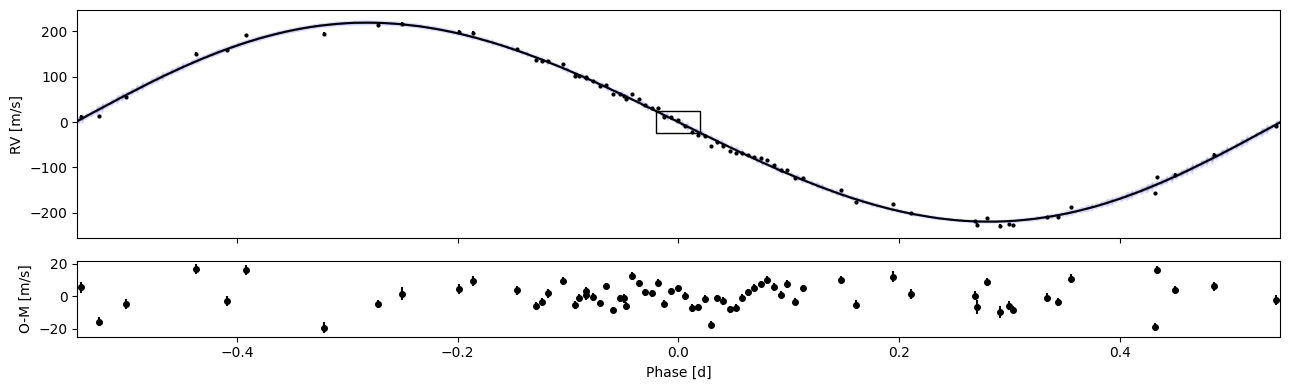

In [65]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
fig.axes[0].add_patch(Rectangle((-.02, -25), 0.04, 50, fill=False));

When we zoom a little bit, we can see that we're now actually plotting the probability density of the model. The black line corresponds to the median of the model posterior, and the two shades to the 68% and 95% central posterior limits.

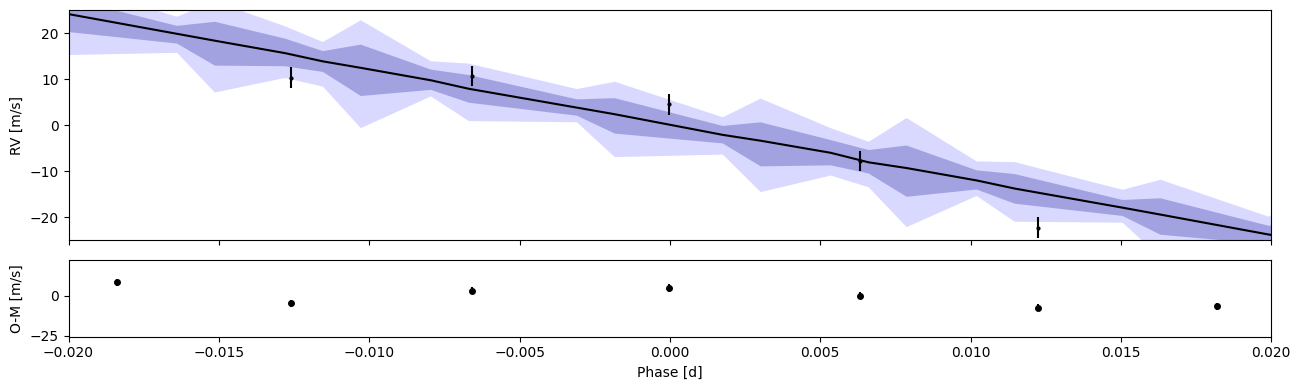

In [66]:
fig = lpf.plot_rv_vs_phase(0, 'mcmc')
setp(fig.axes[0], xlim=(-0.02, 0.02), ylim=(-25,25));

### Plot the parameter posteriors

In [67]:
df = lpf.posterior_samples()
df

,tc_1,p_1,secw_1,sesw_1,rv_shift_0,rv_err_0,rv_k_1,rv_slope_1
0,2.458481e+06,1.091424,0.007022,-0.198215,13.239091,7.797498,220.261406,0.000008
1,2.458481e+06,1.091425,0.016663,-0.203983,13.207698,8.232756,221.698118,0.000009
2,2.458481e+06,1.091426,0.021650,-0.211685,13.614746,7.694674,222.691428,0.000009
3,2.458481e+06,1.091425,0.030560,-0.213170,13.880171,7.361211,222.094834,0.000007
4,2.458481e+06,1.091425,-0.005336,-0.195545,13.785908,7.163590,220.899232,0.000005
...,...,...,...,...,...,...,...,...
9995,2.458481e+06,1.091423,0.023277,-0.177042,14.241974,8.496775,224.343208,0.000006
9996,2.458481e+06,1.091424,0.034050,-0.196066,14.232662,8.110324,226.227045,0.000010
9997,2.458481e+06,1.091423,0.031021,-0.186432,14.766170,7.544342,224.484089,0.000008
9998,2.458481e+06,1.091423,0.039711,-0.176035,15.284812,8.187084,227.035324,0.000008


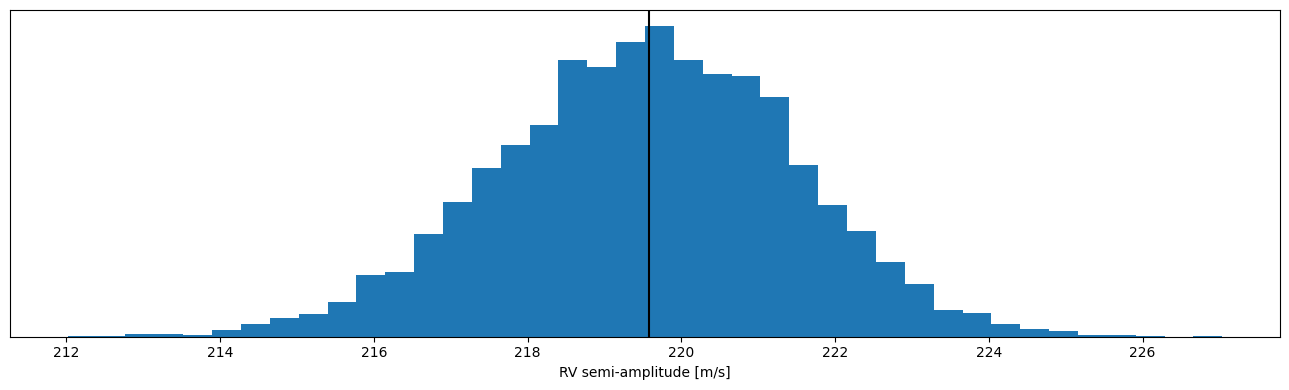

In [68]:
fig, ax = subplots()
ax.hist(df.rv_k_1, bins=40)
ax.axvline(median(df.rv_k_1), c='k')
setp(ax, xlabel='RV semi-amplitude [m/s]', yticks=[])
fig.tight_layout()

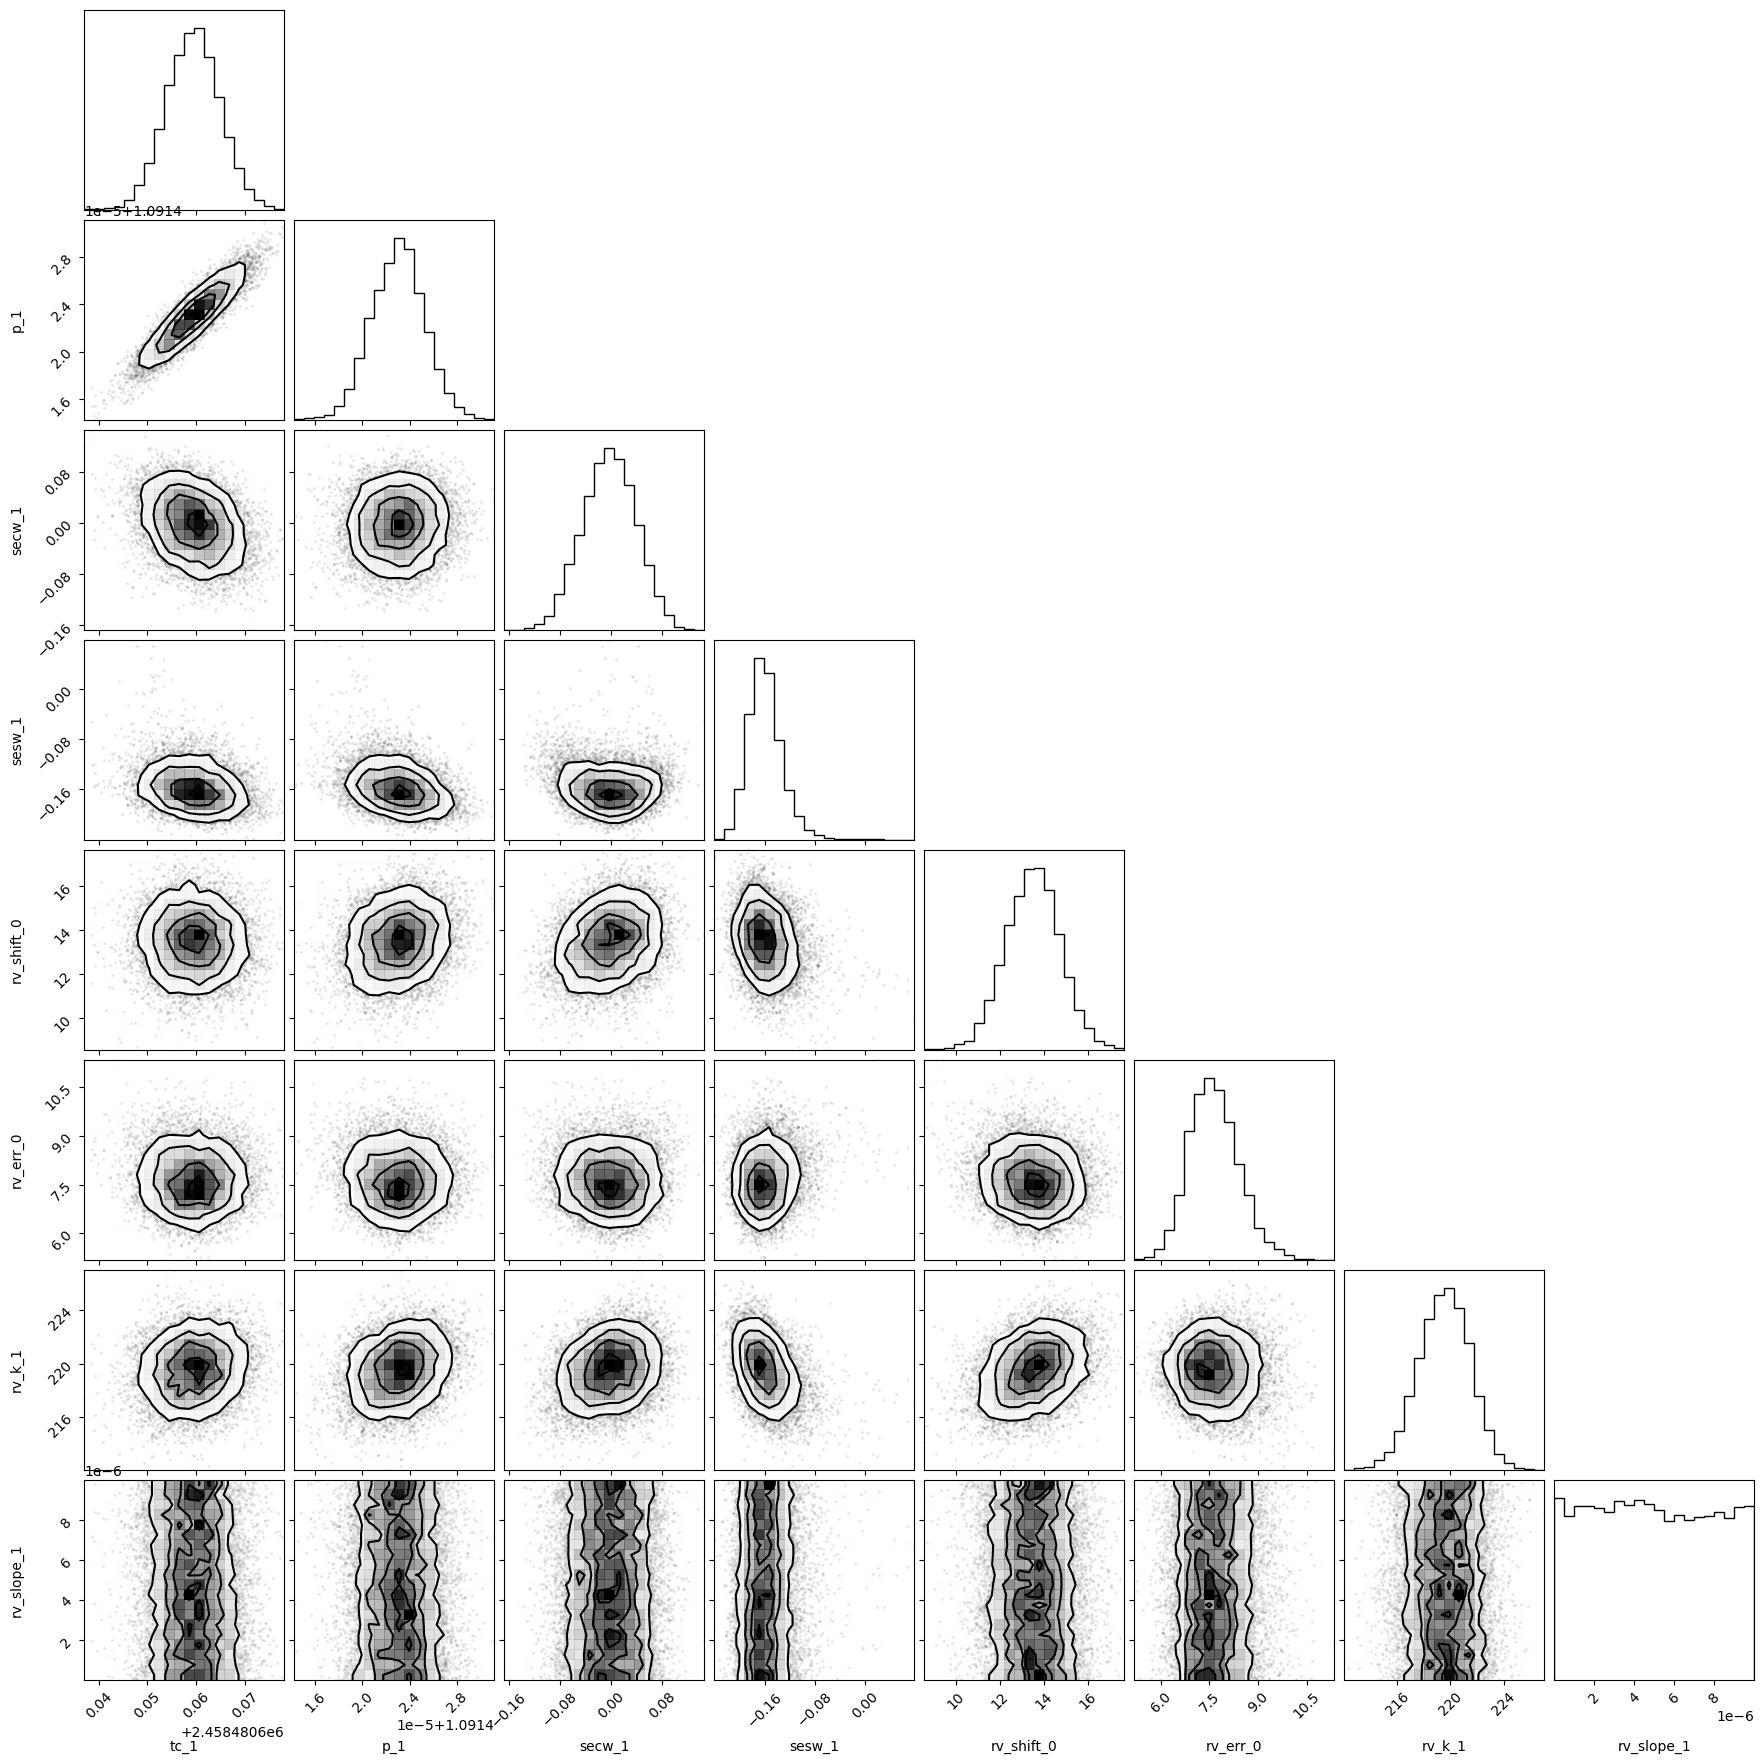

In [69]:
corner(df.values, labels=df.columns);

### <span style="color:darkblue">Questions and exercises</span>

1. We parameterise the model using ($\sqrt{e}\sin\omega$, $\sqrt{e}\cos\omega$) instead of ($e$, $\omega$). This parameterisation is more efficient to sample with an MCMC sampler, but means we need to take some extra steps to get the eccentricity and argument of periastron samples. Write below the equations you need to use to map the sampling parameters to $e$ and $\omega$?

The transformation from the sampled parameters $\sqrt{e} \sin \omega$ and $\sqrt{e} \cos \omega$ to the physical parameters e (eccentricity) and $\omega$ (argument of periastron) is done using the following equations:

$e = (secw)^2 + (sesw)^2 = (\sqrt{e} \sin \omega)^2 + (\sqrt{e} \cos \omega$)^2

$\omega = arctan2(secw,sesw) = arctan2(\sqrt{e} \sin \omega, \sqrt{e} \cos \omega)$

These transformations allow us to correctly reconstruct the physical orbital parameters from the sampled variables. By combining $\sqrt{e}\sin\omega$ and $\sqrt{e}\cos\omega$, we recover the true eccentricity $e$, while the two-argument arctangent function ensures an accurate determination of the argument of periastron \omega across all quadrants. This method improves sampling efficiency without losing the physical meaning of the orbital elements.


2. Derive $e$ and $\omega$ from the MCMC samples and plot their histograms.

We are going to derive the orbital eccentricity and the argument of periastron from the MCMC posterior samples. 

The eccentricity is calculated as previously described, and the argument of periastron is similarly obtained using the earlier presented method as well.

Below, we plot the histograms of both parameters to visualize their posterior distributions.

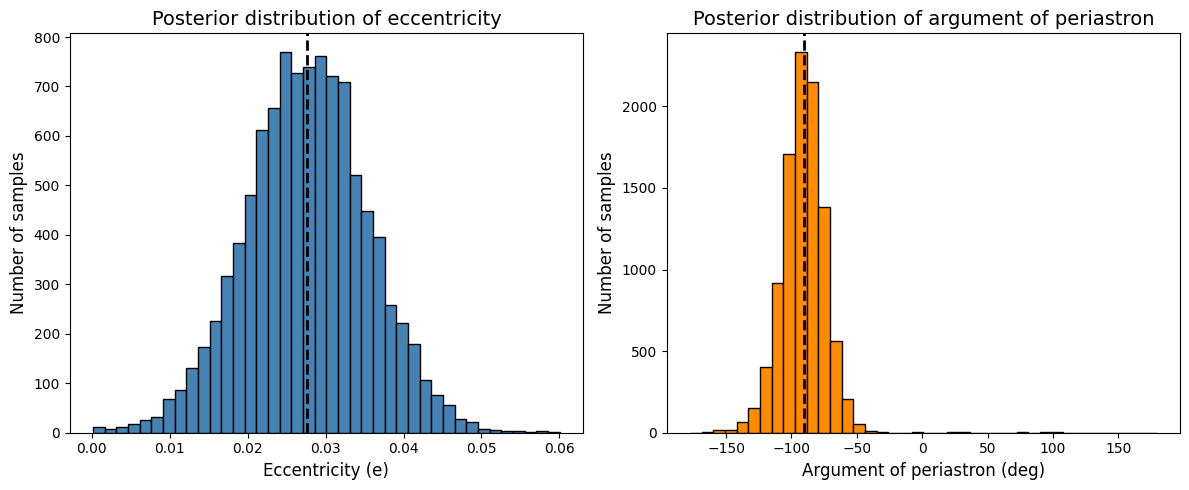

Estimated eccentricity: 0.0277
Estimated argument of periastron: -90.792 degrees


In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Calculate eccentricity and argument of periastron from MCMC samples
e_samples = df['secw_1']**2 + df['sesw_1']**2
omega_samples = np.arctan2(df['secw_1'], df['sesw_1'])

# Create the plots
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of eccentricity
axs[0].hist(e_samples, bins=40, color='steelblue', edgecolor='black')
axs[0].axvline(np.median(e_samples), color='k', linestyle='dashed', linewidth=2)
axs[0].set_xlabel('Eccentricity (e)', fontsize=12)
axs[0].set_ylabel('Number of samples', fontsize=12)
axs[0].set_title('Posterior distribution of eccentricity', fontsize=14)

# Calculate the argument of periastron
omega = np.arctan2(df.sesw_1, df.secw_1)  # Use the correct omega data
omega_deg = omega * 180 / np.pi  # Convert to degrees

# Visualize histogram
axs[1].hist(omega_deg, bins=40, color='darkorange', edgecolor='black')
axs[1].axvline(np.median(omega_deg), color='k', linestyle='dashed', linewidth=2)
axs[1].set_xlabel('Argument of periastron (deg)', fontsize=12)
axs[1].set_ylabel('Number of samples', fontsize=12)
axs[1].set_title('Posterior distribution of argument of periastron', fontsize=14)

plt.tight_layout()
plt.show()

# Print the median of eccentricity and argument of periastron
print(f"Estimated eccentricity: {np.median(e_samples):.4f}")
print(f"Estimated argument of periastron: {np.median(omega_deg):.3f} degrees")

3. What is the posterior density for the minimum mass ($m\sin i$) of WASP-12b? You can derive this from the RV semi-amplitude (K), orbital period (p), and the host star mass.

In order to simplify the calculation of the minimum mass ($M_p \sin i $) from the observed radial velocity semi-amplitude K, we make two standard approximations: 

- First, we assume that the mass of the planet is negligible compared to the mass of the host star, so that:
  $M_\star + M_p \approx M_\star$.

- Second, we consider that the orbital eccentricity is close to zero, $e \approx 0$, meaning the correction factor $(1 - e^2)^{-1/2}$ becomes approximately one. This assumption is based on information obtained from Wikipedia for this planet, where it is indicated that the eccentricity of WASP-12b is nearly zero.

Applying these approximations to the general formula for K,
$$
K = \left(\frac{2\pi G}{P}\right)^{1/3} \frac{M_\mathrm{p} \sin i}{(M_\star + M_\mathrm{p})^{2/3}} \frac{1}{(1-e^2)^{1/2}},
$$

we obtain a simplified expression:

$$
K = \left( \frac{2\pi G}{P} \right)^{1/3} \frac{M_p \sin i}{M_\star^{2/3}}
$$

Below is the Python code used to calculate it:

In [81]:
import numpy as np

# Define constants
G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2
M_sun = 1.98847e30  # Mass of the Sun in kg
M_earth = 5.972e24  # Mass of the Earth in kg
M_jupiter = 1.898e27  # Mass of Jupiter in kg

# Observed parameters (these need to be provided)
K_ms = 220  # RV semi-amplitude in m/s
P_days = 1.09145  # Orbital period in days
M_star = 1.35 * M_sun  # Mass of the star in kg (approximately)

# Convert period from days to seconds
P_seconds = P_days * 24 * 3600

# Calculate m_p * sin(i) in kg using the rearranged formula
mpsini_kg = K_ms / ((2 * np.pi * G) / P_seconds)**(1/3) * M_star**(2/3)

# Convert m_p * sin(i) to Earth masses
mpsini_mearth = mpsini_kg / M_earth

# Convert m_p * sin(i) to Jupiter masses
mpsini_mjup = mpsini_kg / M_jupiter

# Print the calculated value of m_p * sin(i)
print(f"The minimum mass (m_p sin i) is approximately {mpsini_mearth:.9f} M_earth.")
print(f"The minimum mass (m_p sin i) is approximately {mpsini_mjup:.9f} M_jup.")

The minimum mass (m_p sin i) is approximately 432.695210585 M_earth.
The minimum mass (m_p sin i) is approximately 1.361462486 M_jup.


The calculated value of $m_p \sin i$ is approximately 432.7 Earth masses or 1.36 Jupiter masses. This result highlights the significant mass of WASP-12b compared to both the Earth and Jupiter. The value in Earth masses shows how much more massive WASP-12b is compared to our planet, while the value in Jupiter masses emphasizes its size relative to Jupiter. This calculation helps to estimate the minimum mass of the planet, assuming an orbital inclination angle i.

4. What would be the posterior RV semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days?

In [82]:
import numpy as np

# Constants
G = 6.67430e-11  # Gravitational constant in m^3 kg^-1 s^-2
M_sun = 1.98847e30  # Solar mass in kg
M_earth = 5.972e24  # Earth mass in kg
M_jupiter = 1.898e27  # Jupiter mass in kg

# Orbital parameters
P_days = 365  # Orbital period in days for the Earth-mass planet
K_ms = 220  # RV semi-amplitude in m/s (from your posterior)

# Convert period from days to seconds
P_seconds = P_days * 24 * 3600

# Compute K for the Earth-mass planet
K_earth = ( (2 * np.pi * G / P_seconds)**(1/3) ) * (M_earth / (M_sun + M_earth)**(2/3))

print(f"The posterior RV semi-amplitude for an Earth-mass planet with an orbital period of 365 days is approximately {K_earth:.4f} m/s.")


The posterior RV semi-amplitude for an Earth-mass planet with an orbital period of 365 days is approximately 0.0895 m/s.


The calculated value for the radial velocity (RV) semi-amplitude of an Earth-mass planet orbiting WASP-12 with an orbital period of 365 days is approximately 0.0895 m/s. This value was obtained using the standard formula for the radial velocity semi-amplitude, adapted for an Earth-mass planet. In this calculation, the orbital parameters of WASP-12, as well as the mass of the Earth, were used, considering the gravitational influence of the stellar system. It is important to note that the eccentricity of the orbit was assumed to be zero, meaning that the orbit was considered to be circular. This simplification reflects the assumption that the planet’s orbit has no significant eccentricity, and as a result, the calculated RV semi-amplitude is derived under the assumption of a perfectly circular orbit. The result indicates that the amplitude of the signal in the radial velocity measurements would be quite small, reflecting the subtle nature of the motions caused by an Earth-mass planet compared to larger systems such as those of giant planets.

---

<center>&copy;2025 Hannu Parviainen</center>